In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import imageio.v2 as imageio

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate

In [31]:
project_path = os.path.join(os.getcwd(), 'data')
image_path = os.path.join(project_path, 'leftImg8bit_trainvaltest', 'leftImg8bit', 'train')
mask_path = os.path.join(project_path, 'gtFine', 'train')

In [32]:

print("Current working directory:", os.getcwd())
print("Image path:", image_path)
print("Mask path:", mask_path)
print("Image path exists:", os.path.exists(image_path))
print("Mask path exists:", os.path.exists(mask_path))

Current working directory: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation
Image path: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train
Mask path: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train
Image path exists: True
Mask path exists: True


In [33]:
image_list = []
mask_list = []

In [34]:
# Iterate through city subdirectories
for city in os.listdir(image_path):
    city_image_path = os.path.join(image_path, city)
    city_mask_path = os.path.join(mask_path, city)
    
    if os.path.isdir(city_image_path) and not city.startswith('.'):
        image_list.extend([os.path.join(city_image_path, img) for img in os.listdir(city_image_path) if img.endswith('_leftImg8bit.png')])
        mask_list.extend([os.path.join(city_mask_path, msk) for msk in os.listdir(city_mask_path) if msk.endswith('_gtFine_labelIds.png')])

In [35]:
image_list.sort()
mask_list.sort()

In [ ]:
image_list = image_list[:1500]
mask_list = mask_list[:1500]

split_index = int(0.8 * len(image_list))

train_images = image_list[:split_index]
train_masks = mask_list[:split_index]

val_images = image_list[split_index:]
val_masks = mask_list[split_index:]

print("Total images:", len(image_list))
print("Total masks:", len(mask_list))
print("Train images:", len(train_images))
print("Train masks:", len(train_masks))
print("Val images:", len(val_images))
print("Val masks:", len(val_masks))
print("First train image:", train_images[0])
print("First train mask:", train_masks[0])

Number of images: 1500
Number of masks: 1500
First image: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png
First mask: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png


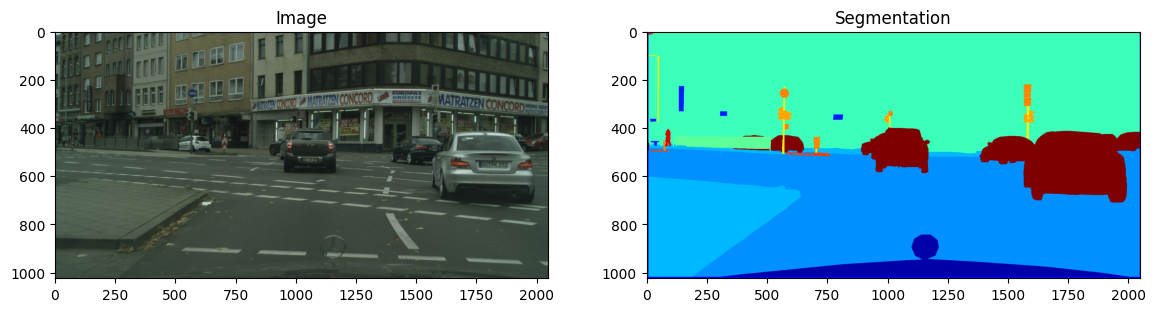

In [37]:
N = 3
img = imageio.imread(image_list[N])
mask = imageio.imread(mask_list[N])
#mask = np.array([max(mask[i, j]) for i in range(mask.shape[0]) for j in range(mask.shape[1])]).reshape(img.shape[0], img.shape[1])

fig, arr = plt.subplots(1, 2, figsize=(14, 10))
arr[0].imshow(img)
arr[0].set_title('Image')
arr[1].imshow(mask, cmap='jet')
arr[1].set_title('Segmentation')
plt.show()

In [38]:
image_list_ds = tf.data.Dataset.list_files(image_list, shuffle=False)
mask_list_ds = tf.data.Dataset.list_files(mask_list, shuffle=False)

for path in zip(image_list_ds.take(3), mask_list_ds.take(3)):
    print(path)

(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000001_000019_leftImg8bit.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000001_000019_gtFine_labelIds.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000002_000019_leftImg8bit.png'>, <tf.

In [ ]:
train_image_filenames = tf.constant(train_images)
train_mask_filenames = tf.constant(train_masks)

val_image_filenames = tf.constant(val_images)
val_mask_filenames = tf.constant(val_masks)

train_raw_dataset = tf.data.Dataset.from_tensor_slices((train_image_filenames, train_mask_filenames))
val_raw_dataset = tf.data.Dataset.from_tensor_slices((val_image_filenames, val_mask_filenames))

for image, mask in train_raw_dataset.take(1):
    print("Train sample:")
    print(image)
    print(mask)

for image, mask in val_raw_dataset.take(1):
    print("Validation sample:")
    print(image)
    print(mask)

tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png', shape=(), dtype=string)
tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png', shape=(), dtype=string)


In [40]:
def process_path(image_path, mask_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    return img, mask

In [41]:
def preprocess(image, mask):
    input_image = tf.image.resize(image, (96, 128), method='nearest')
    input_mask = tf.image.resize(mask, (96, 128), method='nearest')
    return input_image, input_mask

In [ ]:
train_image_ds = train_raw_dataset.map(process_path)
train_processed_ds = train_image_ds.map(preprocess)

val_image_ds = val_raw_dataset.map(process_path)
val_processed_ds = val_image_ds.map(preprocess)

In [43]:
def conv_block(inputs = None, n_filters = 32, dropout_prob = 0, max_pooling = True):
    conv = Conv2D(n_filters, 3, activation='relu', padding= 'same', kernel_initializer= 'he_normal') (inputs)
    conv = Conv2D(n_filters, 3, activation='relu', padding= 'same', kernel_initializer= 'he_normal') (conv)
    
    if dropout_prob > 0:
        conv = Dropout(dropout_prob)(conv)
    
    if max_pooling:
        next_layer = MaxPooling2D(2, strides=2)(conv)
    else:
        next_layer = conv
    
    skip_connection = conv

    return next_layer, skip_connection


In [44]:
def upsampling_block(expansive_output, contractive_output, n_filters = 32):
    up = Conv2DTranspose(n_filters, 3, strides=2, padding='same') (expansive_output)
    merge = concatenate([up, contractive_output], axis=3)

    conv = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(merge)
    conv = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(conv)

    return conv


In [45]:
def unet_model(input_size = (96, 128, 3), n_filters = 32, n_classes = 34):

    inputs = Input(input_size)

    cblock1 = conv_block(inputs= inputs, n_filters= n_filters*1)
    cblock2 = conv_block(inputs= cblock1[0], n_filters= n_filters*2)
    cblock3 = conv_block(inputs= cblock2[0], n_filters= n_filters*4)
    cblock4 = conv_block(inputs= cblock3[0], n_filters= n_filters*8, dropout_prob=0.3)
    cblock5 = conv_block(inputs= cblock4[0], n_filters= n_filters*16, dropout_prob=0.3, max_pooling=False)

    ublock6 = upsampling_block(cblock5[0], cblock4[1], n_filters= n_filters*8)
    ublock7 = upsampling_block(ublock6, cblock3[1], n_filters= n_filters*4)
    ublock8 = upsampling_block(ublock7, cblock2[1], n_filters= n_filters*2)
    ublock9 = upsampling_block(ublock8, cblock1[1], n_filters= n_filters*1)

    conv9 = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(ublock9)
    conv10 = Conv2D(n_classes, 1, padding='same')(conv9)

    model = tf.keras.Model(inputs = inputs, outputs = conv10)

    return model



In [46]:
# set model dimensions

img_height = 96
img_width = 128
num_channels = 3

unet = unet_model((img_height, img_width, num_channels))

In [47]:
unet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 128,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 96, 128,   │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 96, 128,   │      9,248 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 48, 64,    │          0 │ conv2d_21[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 48, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 48, 64,    │     36,928 │ conv2d_22[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 24, 32,    │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 24, 32,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 24, 32,    │    147,584 │ conv2d_24[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 12, 16,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 12, 16,    │    295,168 │ max_pooling2d_6[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 12, 16,    │    590,080 │ conv2d_26[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 16,    │          0 │ conv2d_27[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 6, 8, 256) │          0 │ dropout_2[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 6, 8, 512) │  1,180,160 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 6, 8, 512) │  2,359,808 │ conv2d_28[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 6, 8, 512) │          0 │ conv2d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 12, 16,    │  1,179,904 │ dropout_3[0][0] 

 Total params: 8,640,834 (32.96 MB)

 Trainable params: 8,640,834 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
	
unet.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [49]:
def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

(1024, 2048, 1)


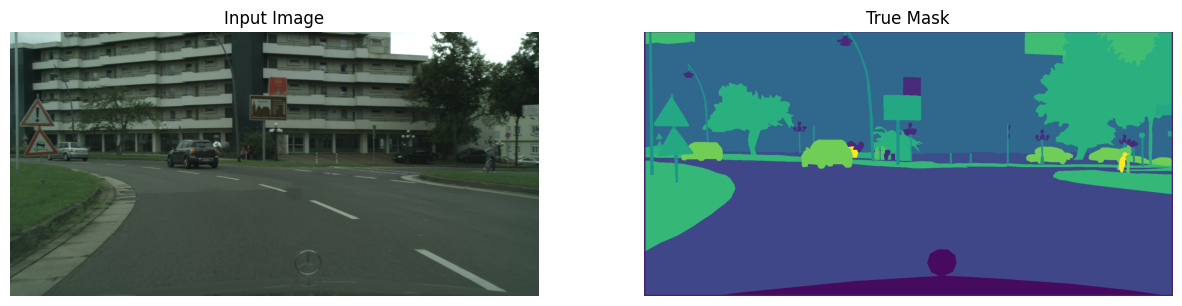

In [ ]:
for image, mask in train_image_ds.take(1):
    sample_image, sample_mask = image, mask
    print("Raw train mask shape:", mask.shape)

display([sample_image, sample_mask])

(96, 128, 1)


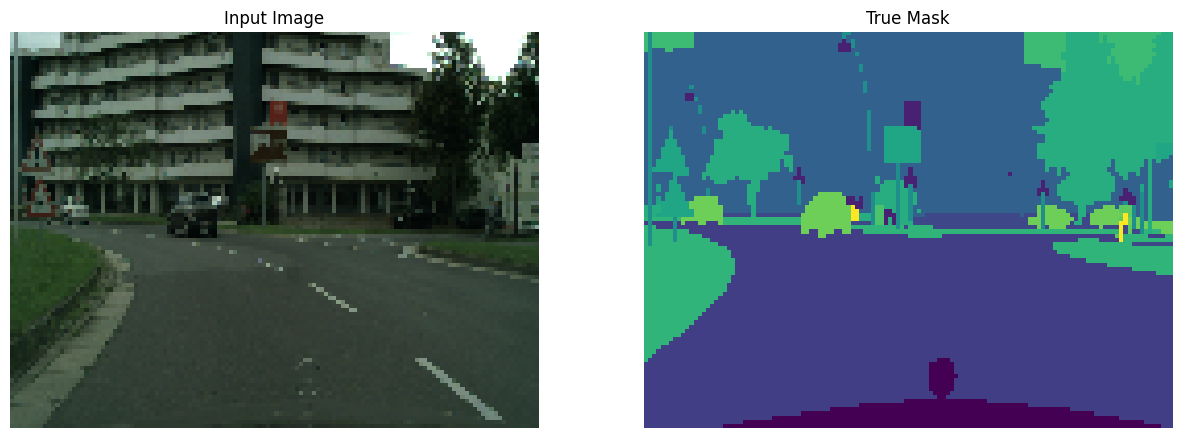

In [ ]:
for image, mask in train_processed_ds.take(1):
    sample_image, sample_mask = image, mask
    print("Processed train mask shape:", mask.shape)

display([sample_image, sample_mask])

In [ ]:
EPOCHS = 15
BUFFER_SIZE = 500
BATCH_SIZE = 16

train_dataset = train_processed_ds.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
val_dataset = val_processed_ds.batch(BATCH_SIZE)

print(train_processed_ds.element_spec)
print(val_processed_ds.element_spec)

model_history = unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

(TensorSpec(shape=(96, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(96, 128, 1), dtype=tf.uint8, name=None))
Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 35s 339ms/step - accuracy: 0.4812 - loss: 1.9491
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 331ms/step - accuracy: 0.6702 - loss: 1.1716
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 342ms/step - accuracy: 0.7255 - loss: 0.9853
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 350ms/step - accuracy: 0.7534 - loss: 0.9046
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 351ms/step - accuracy: 0.7730 - loss: 0.8320
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 352ms/step - accuracy: 0.7818 - loss: 0.8017
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 354ms/step - accuracy: 0.7954 - loss: 0.7536
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - accuracy: 0.7985 - loss: 0.7429
Epoch 9/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 356ms/step - accuracy: 0.8131 - loss: 0.6871
Epoch 10/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - accuracy: 0.8183 - loss: 0.6674
Epoch 11

In [53]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

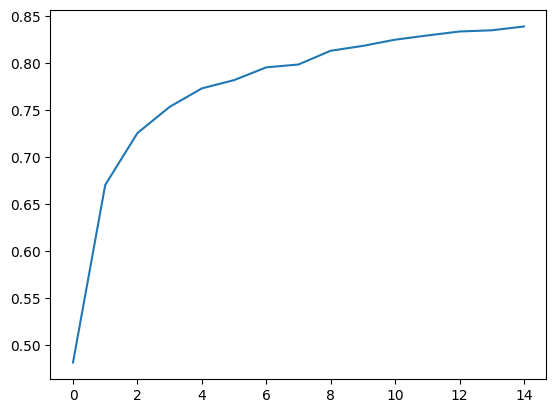

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(model_history.history["accuracy"], label="train_accuracy")
plt.plot(model_history.history["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(model_history.history["loss"], label="train_loss")
plt.plot(model_history.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [55]:
def show_predictions(dataset=None, num=1):

    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = unet.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask,
             create_mask(unet.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


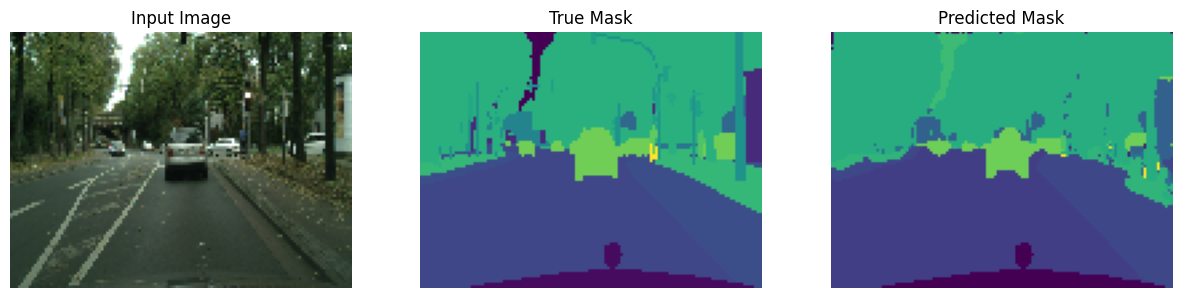

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


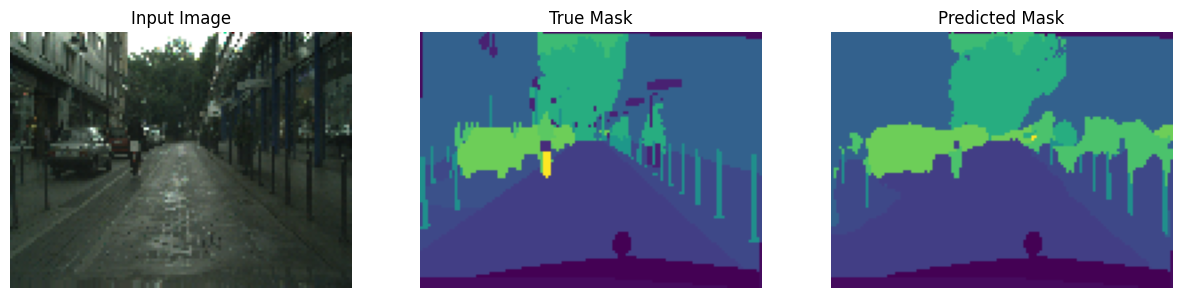

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


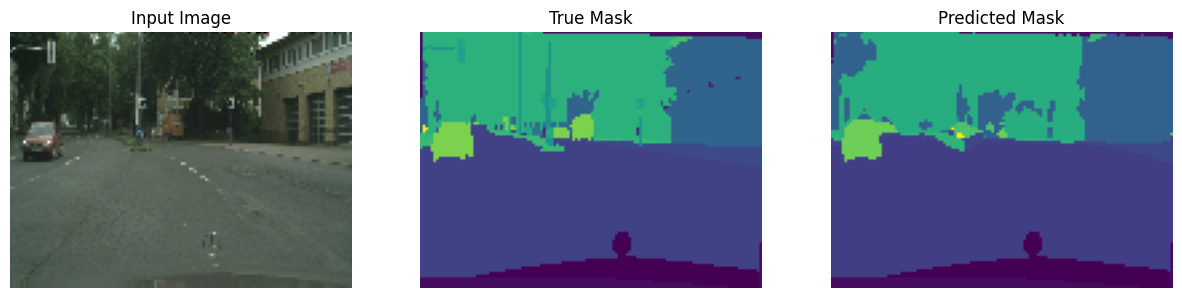

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


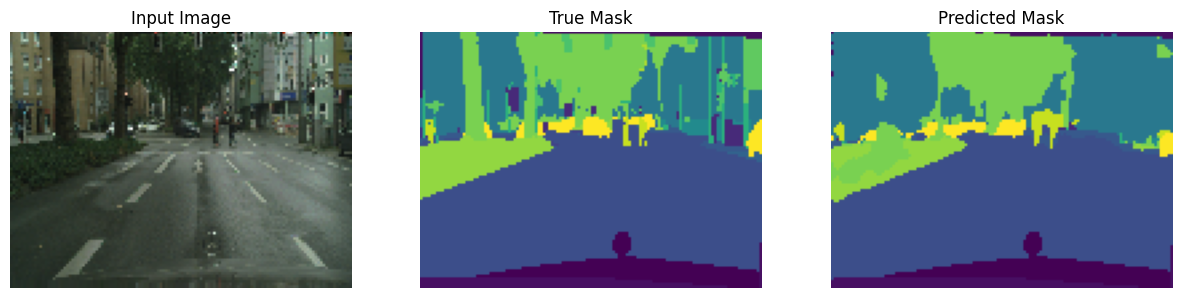

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


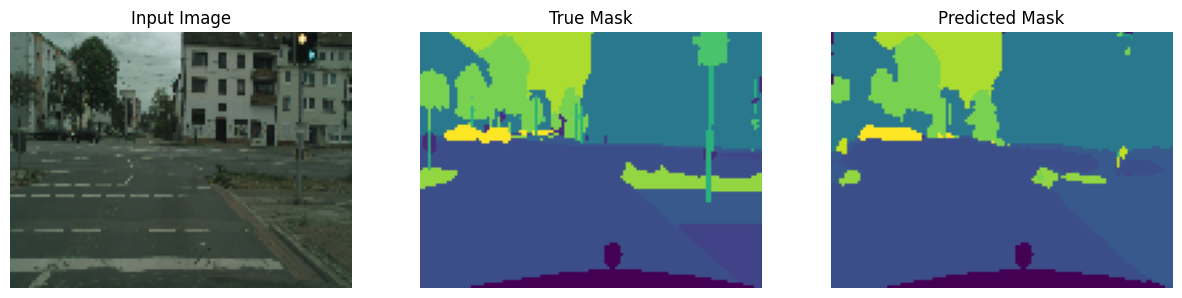

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


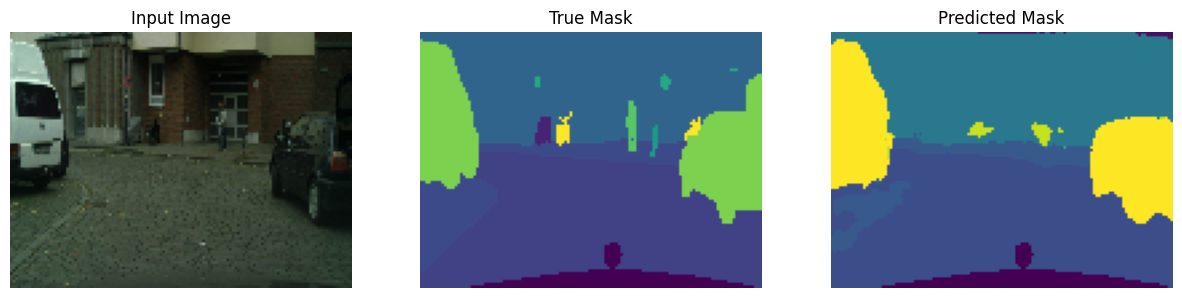

In [56]:
show_predictions(train_dataset, 6)

In [ ]:
show_predictions(val_dataset, 6)